In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)

In [2]:
df = pd.read_csv("../data/interim/merged_sample.csv")

In [3]:
df.shape

(9565, 20)

In [4]:
df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0,0,0,NaN
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0,0,0,NaN
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0,0,0,NaN
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0,0,0,NaN
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0,0,0,NaN


In [5]:
df["date"] = pd.to_datetime(df["date"])

df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0,0,0,NaN
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0,0,0,NaN
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0,0,0,NaN
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0,0,0,NaN
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0,0,0,NaN


In [6]:
# We now want to understand:

# 1. Strong selling stores
# 2. Weak SKUs
# 3. Seasonality
# 4. Promo / Event impact
# 5. Price sensitivity

# These insights become:
# → ML Features
# → Optimization Inputs
# → Business Rules

# Total Sales Per Store

In [7]:
store_sales = (
    df.groupby("store_id")["sales"]
    .sum()
    .sort_values(ascending=False)
)

store_sales

store_id
CA_1    6518
Name: sales, dtype: int64

# Visualize Strong Stores

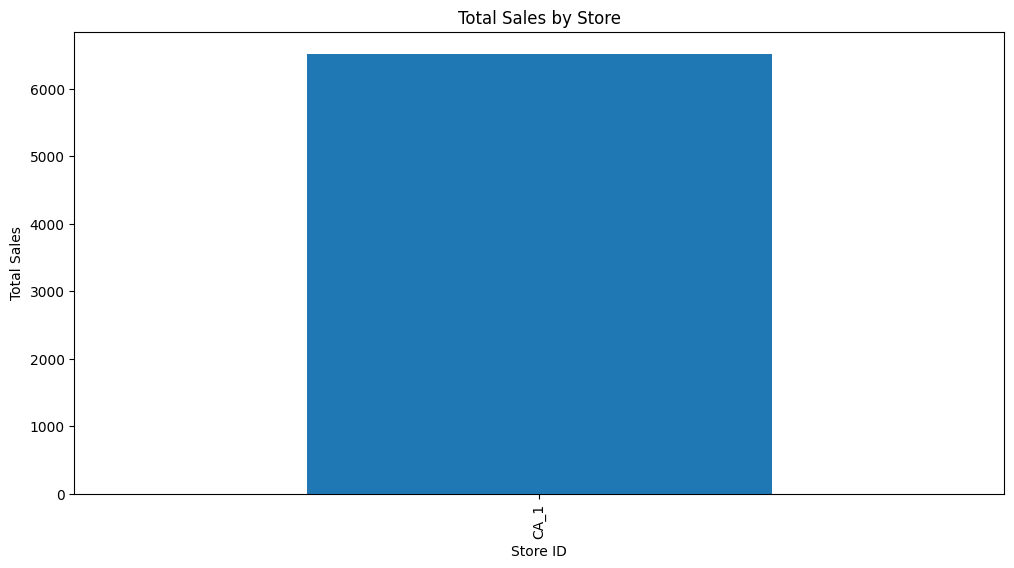

In [8]:
plt.figure(figsize=(12,6))

store_sales.plot(kind="bar")

plt.title("Total Sales by Store")
plt.ylabel("Total Sales")
plt.xlabel("Store ID")

plt.show()

# Average Sales

In [9]:
avg_store_sales = (
    df.groupby("store_id")["sales"]
    .mean()
    .sort_values(ascending=False)
)

avg_store_sales

store_id
CA_1    0.681443
Name: sales, dtype: float64

# Total Sales per SKU

In [11]:
sku_sales = (
    df.groupby("item_id")["sales"]
    .sum()
    .sort_values()
)

sku_sales.head()

item_id
HOBBIES_1_003     288
HOBBIES_1_002     493
HOBBIES_1_001     600
HOBBIES_1_005    1849
HOBBIES_1_004    3288
Name: sales, dtype: int64

In [12]:
weak_skus = sku_sales.head(10)

weak_skus

item_id
HOBBIES_1_003     288
HOBBIES_1_002     493
HOBBIES_1_001     600
HOBBIES_1_005    1849
HOBBIES_1_004    3288
Name: sales, dtype: int64

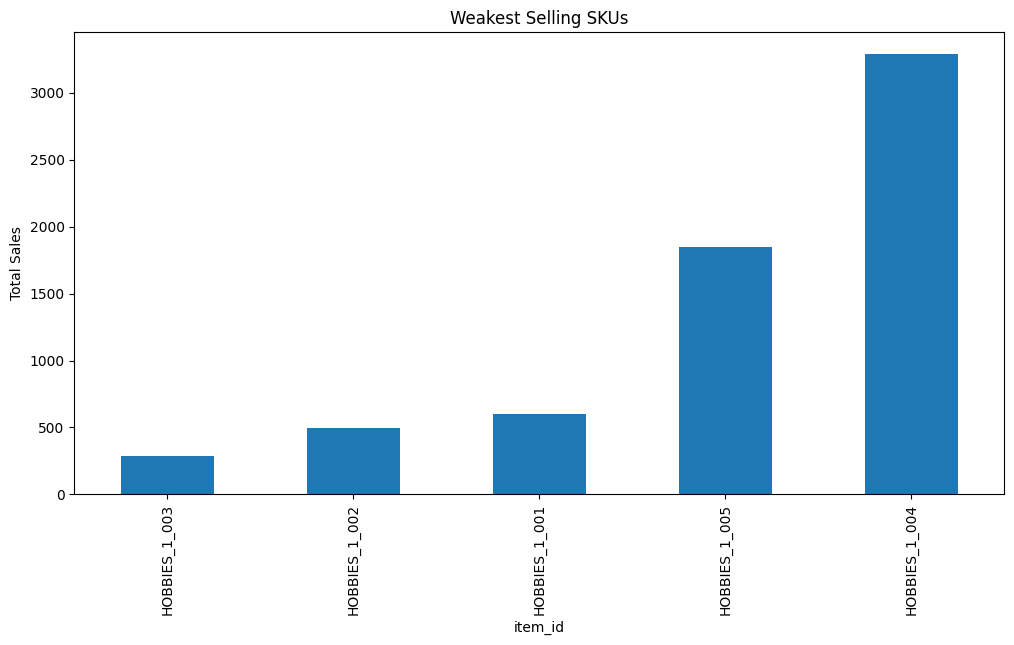

In [13]:
plt.figure(figsize=(12,6))

weak_skus.plot(kind="bar")

plt.title("Weakest Selling SKUs")
plt.ylabel("Total Sales")

plt.show()

# Seasonality

In [14]:
monthly_sales = (
    df.groupby("month")["sales"]
    .mean()
)

monthly_sales

month
1     0.624051
2     0.630588
3     0.629032
4     0.596552
5     0.611613
6     0.614667
7     0.603871
8     0.743226
9     0.773333
10    0.732903
11    0.752000
12    0.895484
Name: sales, dtype: float64

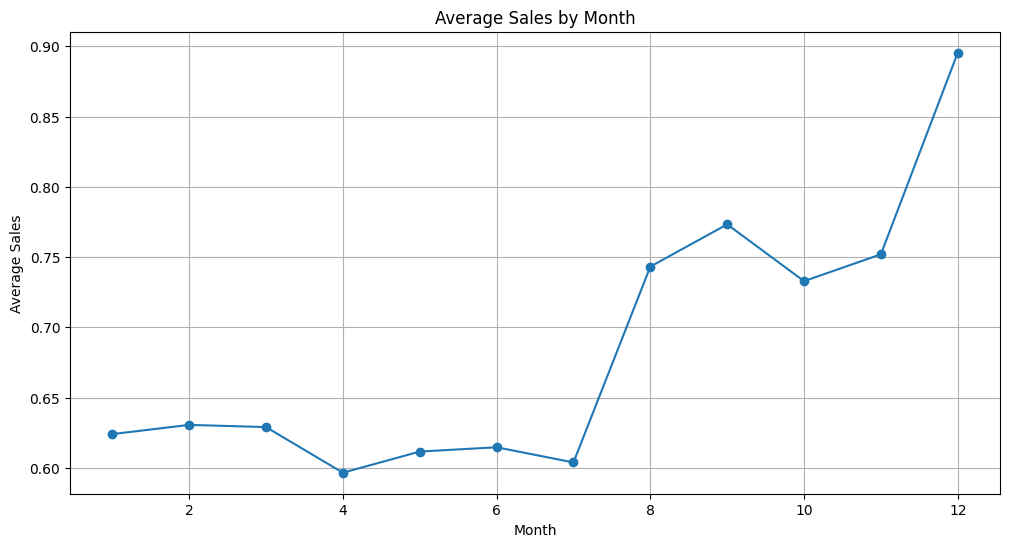

In [15]:
plt.figure(figsize=(12,6))

monthly_sales.plot(marker="o")

plt.title("Average Sales by Month")
plt.ylabel("Average Sales")
plt.xlabel("Month")

plt.grid(True)

plt.show()

In [16]:
weekday_sales = (
    df.groupby("weekday")["sales"]
    .mean()
    .sort_values(ascending=False)
)

weekday_sales

weekday
Sunday       1.040146
Saturday     0.988321
Friday       0.617582
Thursday     0.575824
Monday       0.556044
Tuesday      0.498168
Wednesday    0.491575
Name: sales, dtype: float64

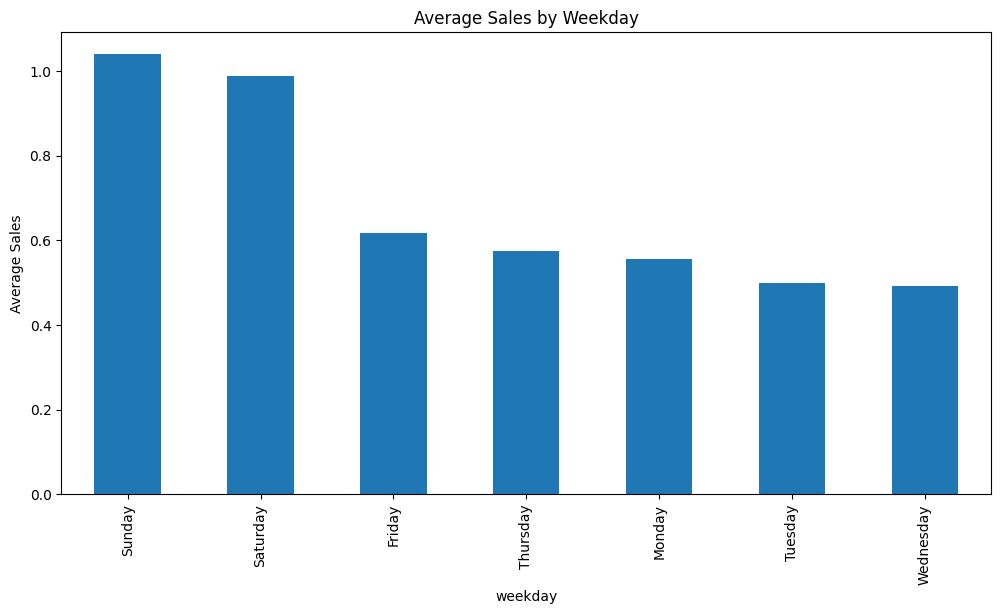

In [17]:
plt.figure(figsize=(12,6))

weekday_sales.plot(kind="bar")

plt.title("Average Sales by Weekday")
plt.ylabel("Average Sales")

plt.show()

# Events and Promotions

In [18]:
df["has_event"] = df["event_name_1"].notnull()

event_sales = (
    df.groupby("has_event")["sales"]
    .mean()
)

event_sales

has_event
False    0.685276
True     0.637662
Name: sales, dtype: float64

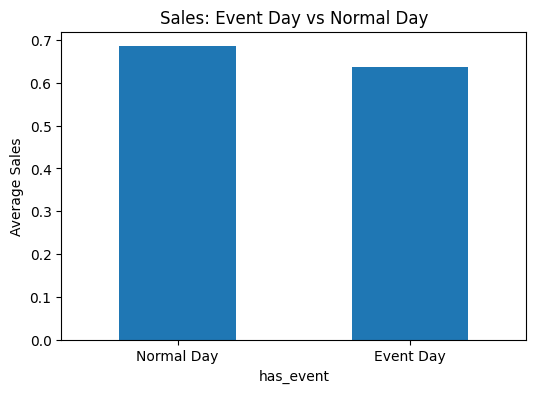

In [19]:
plt.figure(figsize=(6,4))

event_sales.plot(kind="bar")

plt.title("Sales: Event Day vs Normal Day")
plt.ylabel("Average Sales")

plt.xticks([0, 1], ["Normal Day", "Event Day"], rotation=0)

plt.show()

In [20]:
event_type_sales = (
    df.groupby("event_type_1")["sales"]
    .mean()
    .sort_values(ascending=False)
)

event_type_sales

event_type_1
Religious    0.676923
National     0.662745
Cultural     0.588571
Sporting     0.537500
Name: sales, dtype: float64

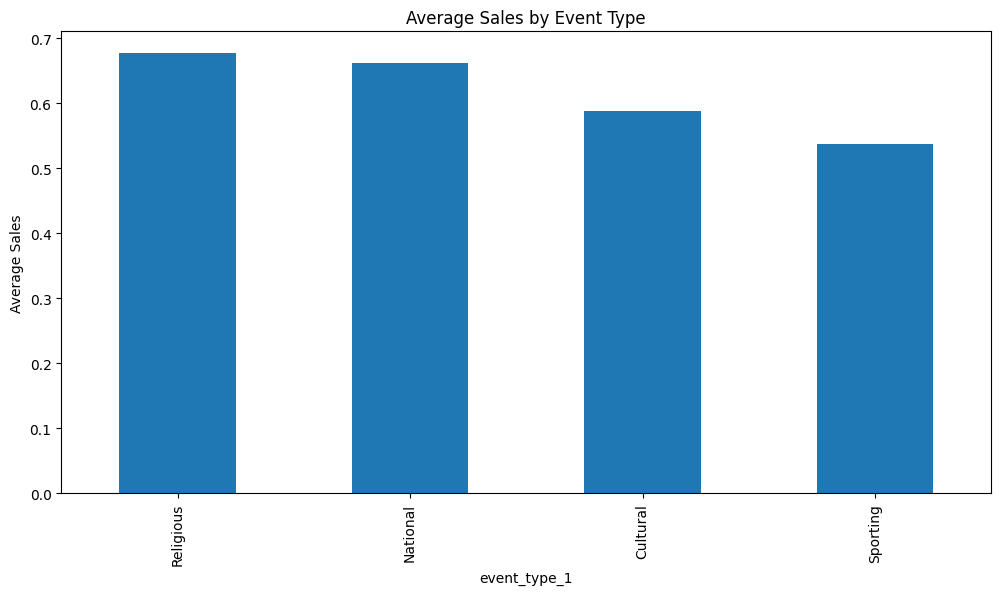

In [21]:
plt.figure(figsize=(12,6))

event_type_sales.plot(kind="bar")

plt.title("Average Sales by Event Type")
plt.ylabel("Average Sales")

plt.show()

In [22]:
price_df = df.dropna(subset=["sell_price"])

print(price_df.shape)

(7283, 21)


In [23]:
correlation = price_df["sell_price"].corr(price_df["sales"])

print("Correlation:", correlation)

Correlation: -0.008448235227786162


# One Product Price Sensitivity

In [24]:
sample_item = price_df["item_id"].iloc[0]

one_product = price_df[
    price_df["item_id"] == sample_item
]

one_product[
    ["date", "sales", "sell_price"]
].head()

,date,sales,sell_price
178,2011-03-05,0,4.34
183,2011-03-06,2,4.34
188,2011-03-07,0,4.34
193,2011-03-08,0,4.34
198,2011-03-09,0,4.34


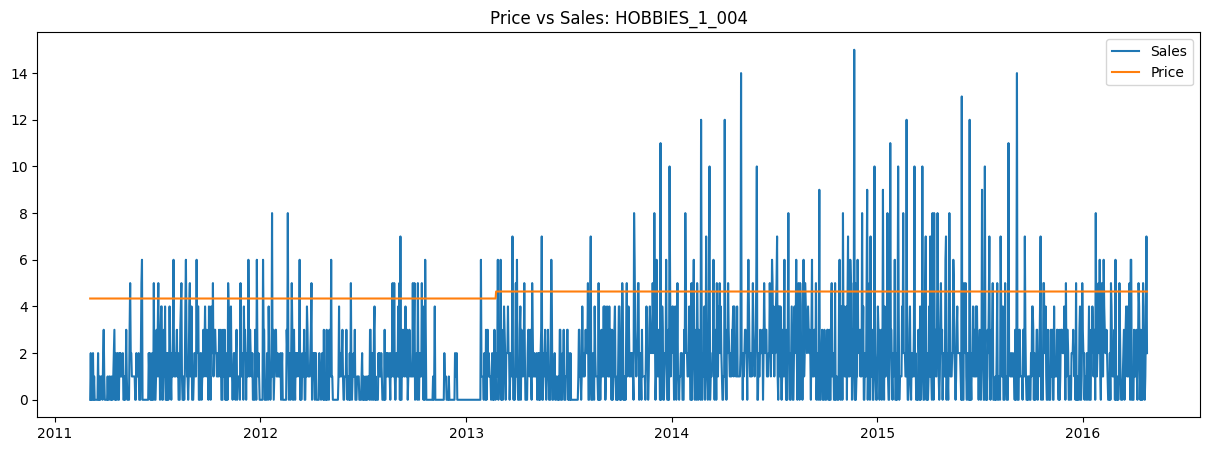

In [25]:
plt.figure(figsize=(15,5))

plt.plot(
    one_product["date"],
    one_product["sales"],
    label="Sales"
)

plt.plot(
    one_product["date"],
    one_product["sell_price"],
    label="Price"
)

plt.title(f"Price vs Sales: {sample_item}")

plt.legend()

plt.show()

In [26]:
# =========================
# CELL 22 — Final Conclusions
# =========================

print("""
================ FINAL CONCLUSIONS ================

1. Strong Selling Stores
--------------------------------
Some stores consistently generate higher sales.
These stores may require:
- larger assortment
- premium SKUs
- higher inventory allocation

2. Weak SKUs
--------------------------------
Some products have consistently poor sales.
These may become:
- reduce candidates
- remove candidates

3. Seasonality Exists
--------------------------------
Sales vary across:
- months
- weekdays
- events

Time-based features are CRITICAL for forecasting.

4. Promotions and Events Matter
--------------------------------
Event days affect customer demand.
Demand spikes happen during:
- religious events
- national events
- SNAP days

5. Price Sensitivity Exists
--------------------------------
Some products react strongly to price changes.
Price becomes an important forecasting feature.

================ ML FOUNDATION ====================

Forecasting model should use:
- lag features
- rolling statistics
- prices
- calendar features
- event indicators
- SNAP indicators

================ OPTIMIZATION FOUNDATION =========

Optimization layer can use:
- predicted demand
- store performance
- weak SKU detection
- price information
- seasonal demand
- business constraints

Final decisions:
- Increase
- Keep
- Reduce
- Remove

===================================================
""")


================ FINAL CONCLUSIONS ================

1. Strong Selling Stores
--------------------------------
Some stores consistently generate higher sales.
These stores may require:
- larger assortment
- premium SKUs
- higher inventory allocation

2. Weak SKUs
--------------------------------
Some products have consistently poor sales.
These may become:
- reduce candidates
- remove candidates

3. Seasonality Exists
--------------------------------
Sales vary across:
- months
- weekdays
- events

Time-based features are CRITICAL for forecasting.

4. Promotions and Events Matter
--------------------------------
Event days affect customer demand.
Demand spikes happen during:
- religious events
- national events
- SNAP days

5. Price Sensitivity Exists
--------------------------------
Some products react strongly to price changes.
Price becomes an important forecasting feature.

================ ML FOUNDATION ====================

Forecasting model should use:
- lag features
- rolling 

In [27]:
# =========================
# CELL 23 — Save Summary Tables
# =========================

store_sales.to_csv("../artifacts/reports/store_sales_summary.csv")

weak_skus.to_csv("../artifacts/reports/weak_skus_summary.csv")

monthly_sales.to_csv("../artifacts/reports/monthly_sales_summary.csv")

event_type_sales.to_csv("../artifacts/reports/event_type_sales_summary.csv")

print("Summary reports saved successfully.")

Summary reports saved successfully.
